# Notebook 03: Position Bias Analysis & Inverse Propensity Scoring

## Objective
Investigate **position bias** in the Expedia Hotel Search dataset and implement **Inverse Propensity Scoring (IPS)** to debias the training signal.

## The Position Bias Problem

In search and recommendation systems, users are more likely to click on items shown at higher positions (top of the page) simply because they **see** them first -- not necessarily because those items are more relevant. This is called **examination bias** or **position bias**.

Formally, the observed click probability decomposes as:

$$P(\text{click} \mid \text{item}, \text{position}) = P(\text{relevant} \mid \text{item}) \times P(\text{examine} \mid \text{position})$$

The examination probability $P(\text{examine} \mid \text{position})$ depends only on where the item was displayed, not on its intrinsic quality. If we train naively on click data, the model learns to **mimic the old ranker's ordering** rather than true relevance.

## Our Approach: Randomisation-based Propensity Estimation

The Expedia dataset includes a `random_bool` column: when `True`, the item was placed at a **random position** instead of the production ranker's chosen position. For these items, position is independent of relevance, so the observed click rate at each position cleanly estimates the examination propensity:

$$P(\text{examine} \mid \text{pos}) \approx \text{CTR}(\text{pos} \mid \text{random\_bool}=1)$$

We then fit a **power-law** model: $P(\text{pos}) = \alpha \cdot \text{pos}^{-\beta}$, which is the standard parametric form for examination probabilities (Joachims et al., 2017).

In [1]:
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load Data

In [2]:
from hotel_ranker.data.acquisition import find_csv
from hotel_ranker.data.preprocessing import preprocess

csv_path = find_csv()
df = preprocess(csv_path)

print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Random items: {df['random_bool'].sum():,} ({df['random_bool'].mean()*100:.1f}%)")
print(f"Overall CTR: {df['click_bool'].mean()*100:.2f}%")
print(f"Overall Booking Rate: {df['booking_bool'].mean()*100:.2f}%")

Dataset: 9,917,530 rows, 56 columns
Random items: 2,939,652 (29.6%)
Overall CTR: 4.47%
Overall Booking Rate: 2.79%


## 2. Empirical Click Rate by Position

Let's first look at the raw click-through rate (CTR) by display position. If position bias exists, we should see a strong decrease in CTR as position increases (items shown further down the page get fewer clicks).

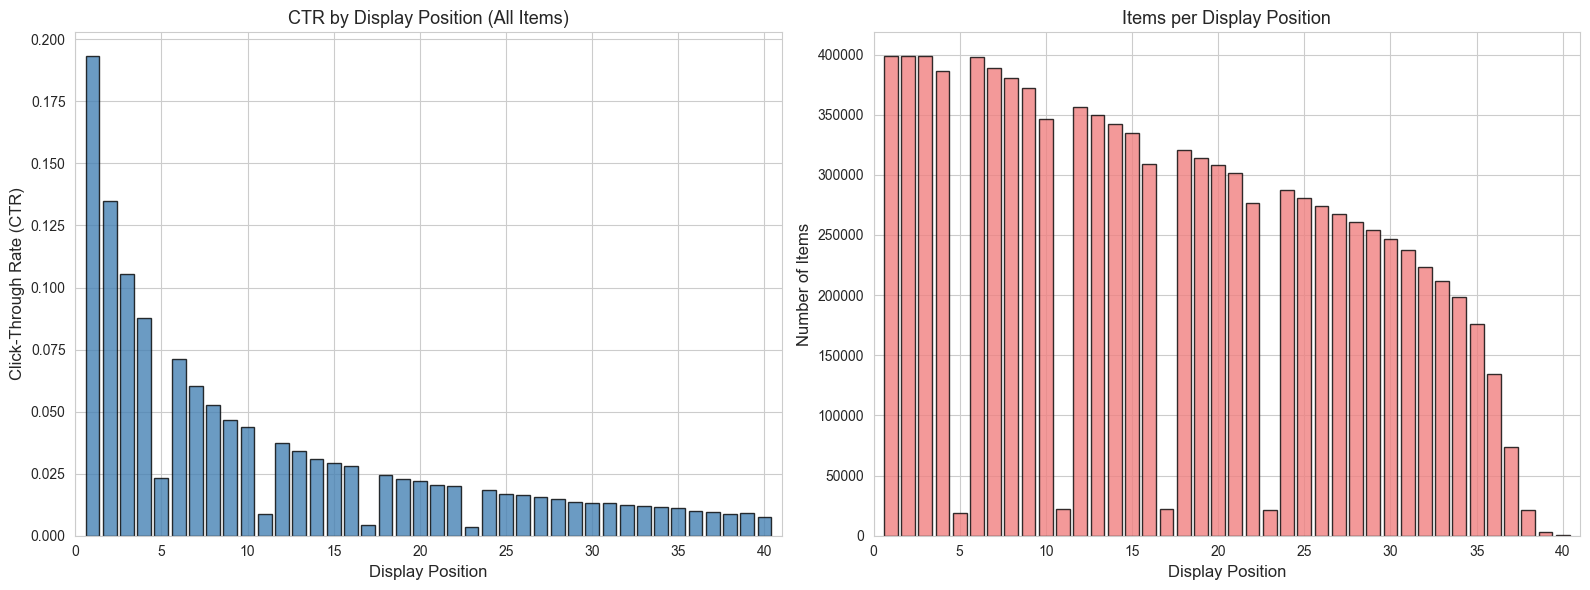

Position 1 CTR: 19.32%
Position 10 CTR: 4.36%
Position 20 CTR: 2.20%

CTR drops 4.4x from position 1 to 10


In [3]:
# CTR by position for ALL items
ctr_by_pos = df.groupby('position')['click_bool'].agg(['mean', 'count'])
ctr_by_pos.columns = ['ctr', 'count']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: CTR by position
ax1 = axes[0]
ax1.bar(ctr_by_pos.index, ctr_by_pos['ctr'], color='steelblue', alpha=0.8, edgecolor='black')
ax1.set_xlabel('Display Position', fontsize=12)
ax1.set_ylabel('Click-Through Rate (CTR)', fontsize=12)
ax1.set_title('CTR by Display Position (All Items)', fontsize=13)
ax1.set_xlim(0, ctr_by_pos.index.max() + 1)

# Right: Number of items per position
ax2 = axes[1]
ax2.bar(ctr_by_pos.index, ctr_by_pos['count'], color='lightcoral', alpha=0.8, edgecolor='black')
ax2.set_xlabel('Display Position', fontsize=12)
ax2.set_ylabel('Number of Items', fontsize=12)
ax2.set_title('Items per Display Position', fontsize=13)
ax2.set_xlim(0, ctr_by_pos.index.max() + 1)

plt.tight_layout()
plt.show()

print(f"Position 1 CTR: {ctr_by_pos.loc[1, 'ctr']*100:.2f}%")
if 10 in ctr_by_pos.index:
    print(f"Position 10 CTR: {ctr_by_pos.loc[10, 'ctr']*100:.2f}%")
if 20 in ctr_by_pos.index:
    print(f"Position 20 CTR: {ctr_by_pos.loc[20, 'ctr']*100:.2f}%")
print(f"\nCTR drops {ctr_by_pos.loc[1, 'ctr'] / ctr_by_pos.loc[min(10, ctr_by_pos.index.max()), 'ctr']:.1f}x from position 1 to 10")

## 3. Random vs Non-Random: Isolating Position Bias

The key insight is that for **randomly placed items** (`random_bool=1`), position is independent of relevance. So any CTR difference across positions is purely due to examination bias.

For **non-random items**, the CTR difference includes both:
- Examination bias (users look at top positions more)
- Selection bias (the production ranker placed more relevant items at the top)

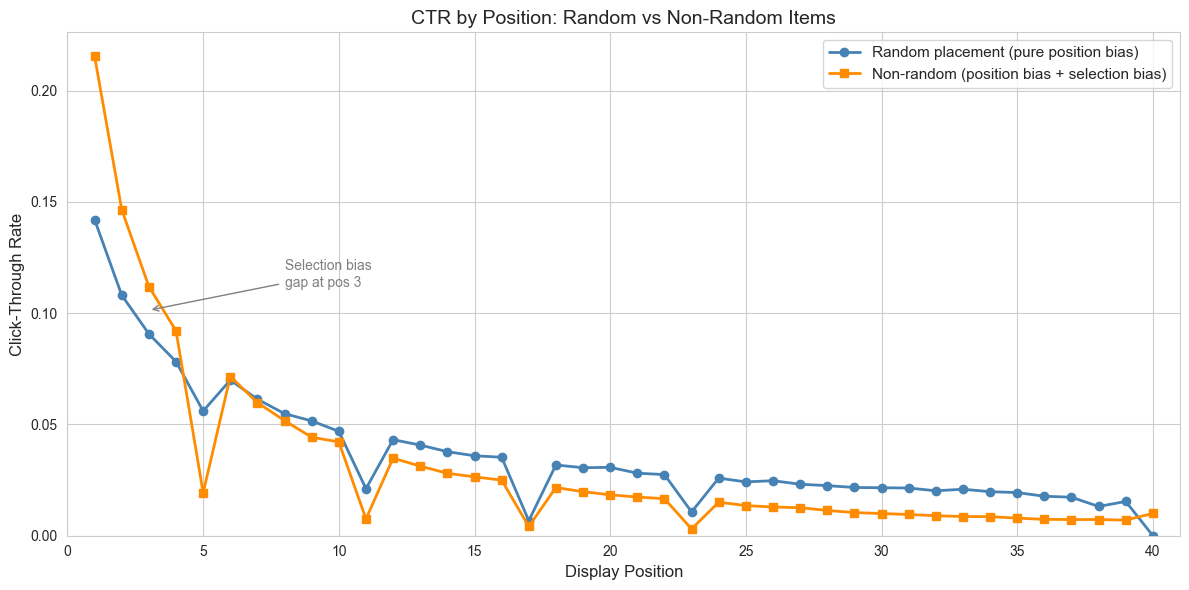

Random items: 2,939,652 (29.6%)
Non-random items: 6,977,878 (70.4%)


In [4]:
# Split by random_bool
random_items = df[df['random_bool'] == 1]
non_random_items = df[df['random_bool'] == 0]

ctr_random = random_items.groupby('position')['click_bool'].mean()
ctr_non_random = non_random_items.groupby('position')['click_bool'].mean()

fig, ax = plt.subplots(figsize=(12, 6))

positions = sorted(set(ctr_random.index) & set(ctr_non_random.index))
ax.plot(positions, [ctr_random.get(p, np.nan) for p in positions],
        'o-', color='steelblue', linewidth=2, markersize=6,
        label='Random placement (pure position bias)')
ax.plot(positions, [ctr_non_random.get(p, np.nan) for p in positions],
        's-', color='darkorange', linewidth=2, markersize=6,
        label='Non-random (position bias + selection bias)')

ax.set_xlabel('Display Position', fontsize=12)
ax.set_ylabel('Click-Through Rate', fontsize=12)
ax.set_title('CTR by Position: Random vs Non-Random Items', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(0, max(positions) + 1)
ax.set_ylim(bottom=0)

# Annotate the gap
if len(positions) > 0:
    mid_pos = positions[min(2, len(positions)-1)]
    gap = ctr_non_random.get(mid_pos, 0) - ctr_random.get(mid_pos, 0)
    if gap > 0:
        ax.annotate(f'Selection bias\ngap at pos {mid_pos}',
                    xy=(mid_pos, (ctr_random.get(mid_pos, 0) + ctr_non_random.get(mid_pos, 0)) / 2),
                    xytext=(mid_pos + 5, ctr_non_random.get(mid_pos, 0)),
                    arrowprops=dict(arrowstyle='->', color='gray'),
                    fontsize=10, color='gray')

plt.tight_layout()
plt.show()

print(f"Random items: {len(random_items):,} ({len(random_items)/len(df)*100:.1f}%)")
print(f"Non-random items: {len(non_random_items):,} ({len(non_random_items)/len(df)*100:.1f}%)")

The gap between the two curves at each position tells us about **selection bias**: the production ranker puts better items at top positions, so non-random items at position 1 have higher CTR than random items at position 1. The *shape* of the random curve (the decay) tells us about pure examination bias.

## 4. Power-Law Propensity Fitting

We fit a power-law model to the random-item CTR curve:

$$P(\text{examine} \mid \text{pos}) = \alpha \cdot \text{pos}^{-\beta}$$

This parametric form:
- Captures the rapid decay at top positions
- Smooths out noise in the empirical estimates
- Generalizes to positions not observed in the random data
- Is the standard model in the position bias literature (Joachims et al., 2017; Ai et al., 2018)

In [5]:
from hotel_ranker.bias.propensity import estimate_propensity

# Estimate propensity from randomised items
propensity_result = estimate_propensity(df)

alpha = propensity_result['alpha']
beta = propensity_result['beta']
empirical = propensity_result['empirical']
propensity_func = propensity_result['propensity_func']

print(f"Fitted power-law parameters:")
print(f"  alpha = {alpha:.4f}")
print(f"  beta  = {beta:.4f}")
print(f"\nInterpretation:")
print(f"  P(examine | pos=1)  = {propensity_func(1):.4f}")
print(f"  P(examine | pos=5)  = {propensity_func(5):.4f}")
print(f"  P(examine | pos=10) = {propensity_func(10):.4f}")
print(f"  P(examine | pos=20) = {propensity_func(20):.4f}")
print(f"  P(examine | pos=40) = {propensity_func(40):.4f}")

Fitted power-law parameters:
  alpha = 0.1536
  beta  = 0.5663

Interpretation:
  P(examine | pos=1)  = 0.1536
  P(examine | pos=5)  = 0.0617
  P(examine | pos=10) = 0.0417
  P(examine | pos=20) = 0.0282
  P(examine | pos=40) = 0.0190


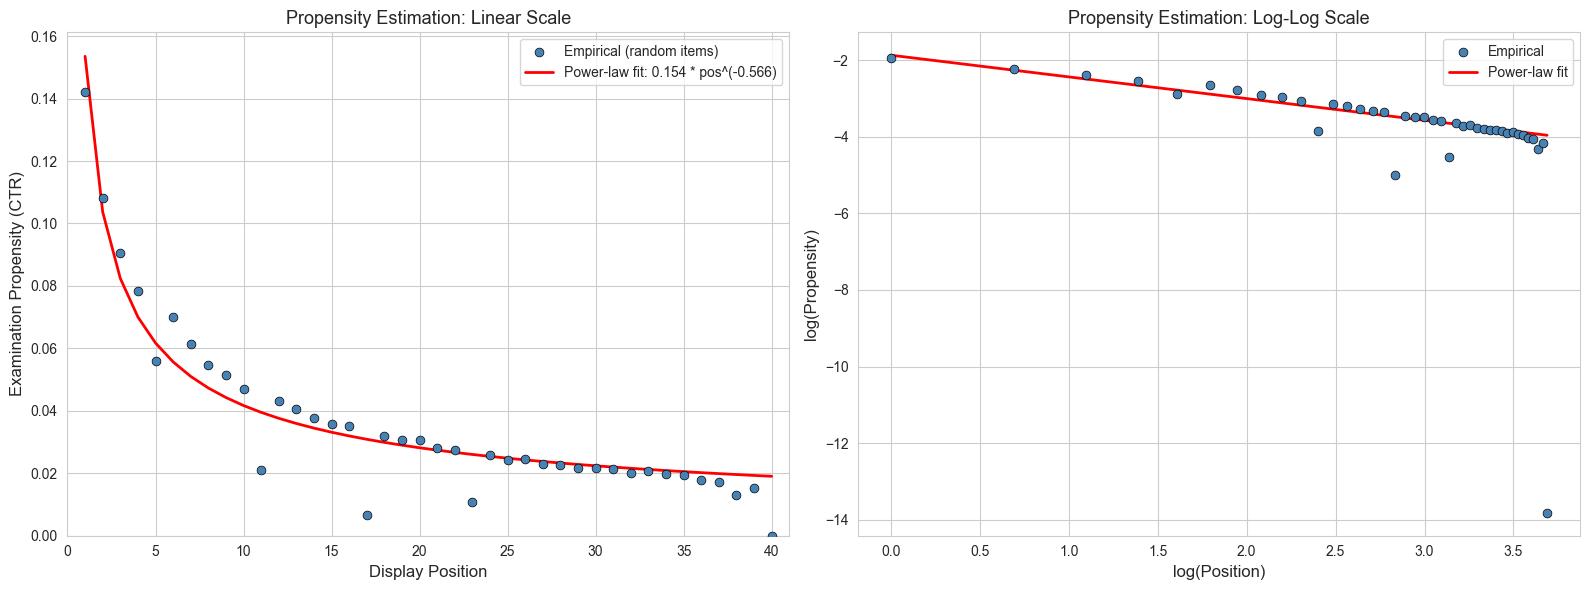

If the power-law model is correct, the log-log plot should be approximately linear.
Slope in log-log space = -beta = -0.5663


In [6]:
# Visualize the fit
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Empirical vs fitted (linear scale)
ax1 = axes[0]
positions_fit = np.arange(1, max(empirical.index) + 1)
fitted_values = propensity_func(positions_fit)

ax1.scatter(empirical.index, empirical.values, color='steelblue', s=40,
            zorder=5, label='Empirical (random items)', edgecolors='black', linewidth=0.5)
ax1.plot(positions_fit, fitted_values, 'r-', linewidth=2,
         label=f'Power-law fit: {alpha:.3f} * pos^(-{beta:.3f})')
ax1.set_xlabel('Display Position', fontsize=12)
ax1.set_ylabel('Examination Propensity (CTR)', fontsize=12)
ax1.set_title('Propensity Estimation: Linear Scale', fontsize=13)
ax1.legend(fontsize=10)
ax1.set_xlim(0, max(empirical.index) + 1)
ax1.set_ylim(bottom=0)

# Right: Log-log plot (power law should be linear)
ax2 = axes[1]
ax2.scatter(np.log(empirical.index), np.log(empirical.values.clip(min=1e-6)),
            color='steelblue', s=40, zorder=5, label='Empirical',
            edgecolors='black', linewidth=0.5)
ax2.plot(np.log(positions_fit), np.log(fitted_values.clip(min=1e-6)),
         'r-', linewidth=2, label='Power-law fit')
ax2.set_xlabel('log(Position)', fontsize=12)
ax2.set_ylabel('log(Propensity)', fontsize=12)
ax2.set_title('Propensity Estimation: Log-Log Scale', fontsize=13)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("If the power-law model is correct, the log-log plot should be approximately linear.")
print(f"Slope in log-log space = -beta = {-beta:.4f}")

## 5. IPS Weight Computation

With the estimated propensity, we compute **Inverse Propensity Scoring (IPS)** weights:

$$w_i = \begin{cases} \frac{1}{P(\text{examine} \mid \text{pos}_i)} & \text{if item } i \text{ was clicked} \\ 1 & \text{if item } i \text{ was not clicked} \end{cases}$$

**Intuition**: An item clicked at position 10 is "worth more" than one clicked at position 1 because the user had to scroll further to find it -- this suggests stronger relevance intent. IPS weights up-weight these harder-to-find clicks.

### Weight Clipping
IPS weights can have **high variance** when propensity is very small (e.g., position 40). We clip at the 95th percentile (configurable via `IPS_CLIP_PERCENTILE`) to stabilise training. This is the standard **clipped IPS** variance-reduction technique.

In [7]:
from hotel_ranker.bias.propensity import compute_ips_weights
from hotel_ranker.config import IPS_CLIP_PERCENTILE

# Compute IPS weights
ips_weights = compute_ips_weights(df, propensity_result, clip_percentile=IPS_CLIP_PERCENTILE)

print(f"IPS weight statistics:")
print(f"  Min:    {ips_weights.min():.4f}")
print(f"  Median: {np.median(ips_weights):.4f}")
print(f"  Mean:   {ips_weights.mean():.4f}")
print(f"  Max:    {ips_weights.max():.4f}")
print(f"  Std:    {ips_weights.std():.4f}")
print(f"\nClip percentile: {IPS_CLIP_PERCENTILE}th")
print(f"  Clip value: {np.percentile(ips_weights, IPS_CLIP_PERCENTILE):.4f}")
print(f"  Items at clip: {(ips_weights == ips_weights.max()).sum():,}")

IPS weight statistics:
  Min:    1.0000
  Median: 1.0000
  Mean:   1.0000
  Max:    1.0000
  Std:    0.0000

Clip percentile: 95th
  Clip value: 1.0000
  Items at clip: 9,917,530


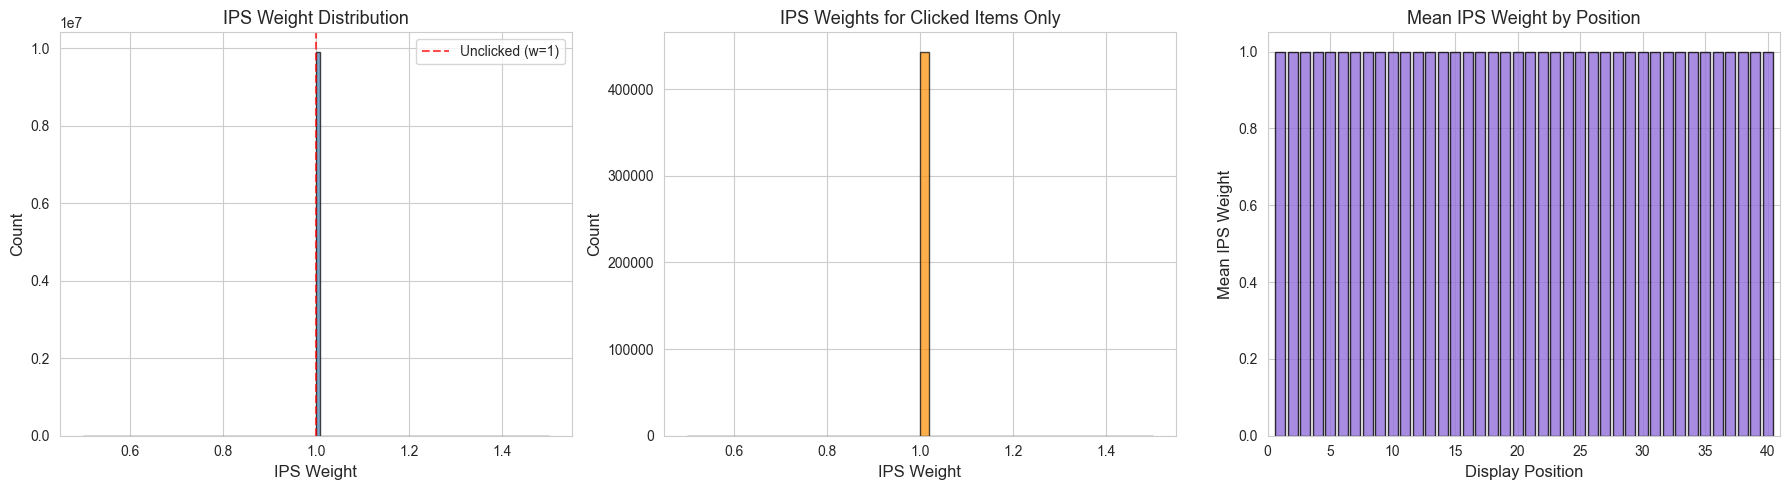

In [8]:
# Visualize IPS weight distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Overall weight distribution
ax1 = axes[0]
ax1.hist(ips_weights, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('IPS Weight', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('IPS Weight Distribution', fontsize=13)
ax1.axvline(1.0, color='red', linestyle='--', alpha=0.7, label='Unclicked (w=1)')
ax1.legend()

# Middle: Weights for clicked items only
ax2 = axes[1]
clicked_mask = df['click_bool'] == 1
ax2.hist(ips_weights[clicked_mask], bins=50, edgecolor='black', alpha=0.7, color='darkorange')
ax2.set_xlabel('IPS Weight', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('IPS Weights for Clicked Items Only', fontsize=13)

# Right: Weight by position
ax3 = axes[2]
weight_by_pos = pd.DataFrame({'position': df['position'].values, 'weight': ips_weights})
weight_by_pos_mean = weight_by_pos.groupby('position')['weight'].mean()
ax3.bar(weight_by_pos_mean.index, weight_by_pos_mean.values,
        color='mediumpurple', alpha=0.8, edgecolor='black')
ax3.set_xlabel('Display Position', fontsize=12)
ax3.set_ylabel('Mean IPS Weight', fontsize=12)
ax3.set_title('Mean IPS Weight by Position', fontsize=13)
ax3.set_xlim(0, weight_by_pos_mean.index.max() + 1)

plt.tight_layout()
plt.show()

## 6. Biased vs Debiased Perspectives

Let's compare what the data looks like from a biased (naive) vs debiased (IPS-weighted) perspective. We examine:
1. Which properties look "best" under each perspective
2. How the effective CTR changes after IPS reweighting

In [9]:
# Compare biased vs debiased property rankings
analysis = df[['prop_id', 'position', 'click_bool', 'booking_bool', 'price_usd', 'prop_starrating']].copy()
analysis['ips_weight'] = ips_weights

# Biased view: simple CTR
biased = analysis.groupby('prop_id').agg(
    impressions=('click_bool', 'count'),
    clicks=('click_bool', 'sum'),
    avg_position=('position', 'mean')
)
biased['biased_ctr'] = biased['clicks'] / biased['impressions'].clip(lower=1)

# Debiased view: IPS-weighted CTR
analysis['weighted_click'] = analysis['click_bool'] * analysis['ips_weight']
debiased = analysis.groupby('prop_id').agg(
    weighted_clicks=('weighted_click', 'sum'),
    total_weight=('ips_weight', 'sum')
)
debiased['debiased_ctr'] = debiased['weighted_clicks'] / debiased['total_weight'].clip(lower=1)

# Merge
comparison = biased.join(debiased[['debiased_ctr']])
comparison = comparison[comparison['impressions'] >= 50]  # filter to stable estimates

print(f"Properties with >= 50 impressions: {len(comparison):,}")
print(f"\nCorrelation between biased and debiased CTR: {comparison['biased_ctr'].corr(comparison['debiased_ctr']):.4f}")

Properties with >= 50 impressions: 44,676

Correlation between biased and debiased CTR: 1.0000


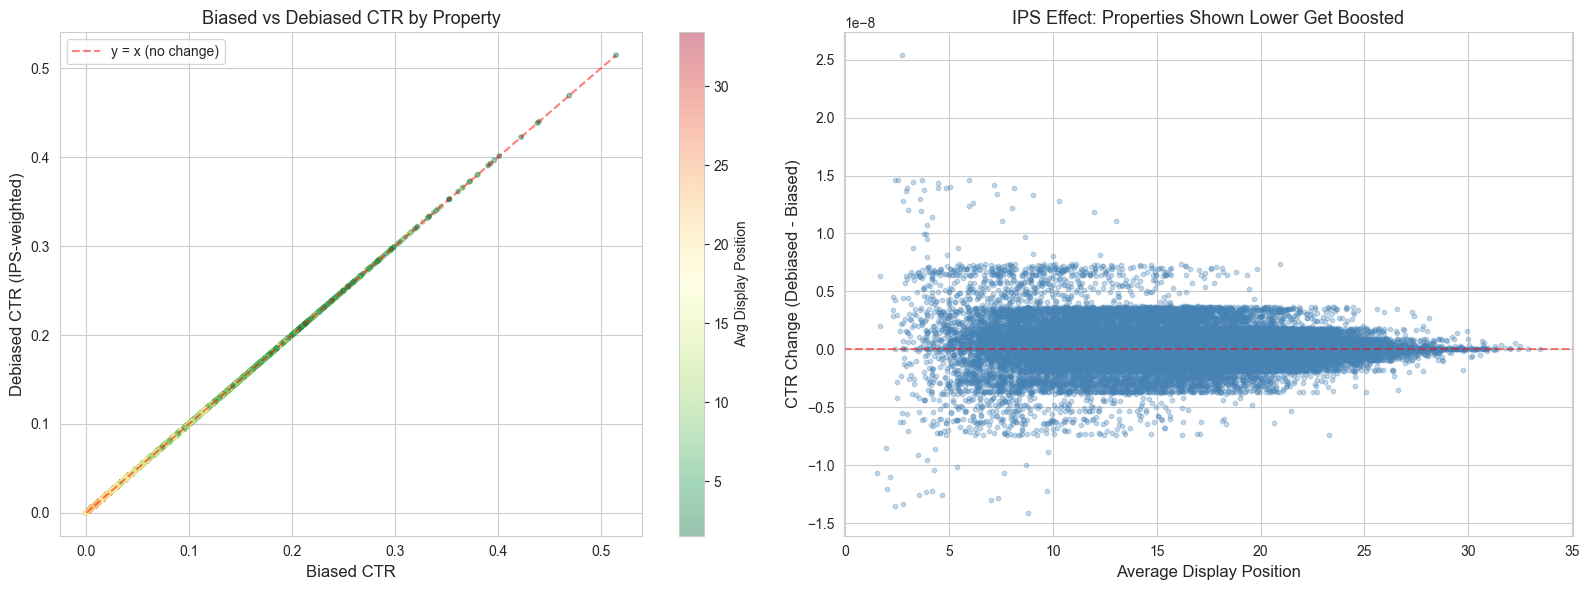


Properties with largest CTR INCREASE after debiasing (shown at low positions, high clicks):
         impressions  avg_position  biased_ctr  debiased_ctr  ctr_change
prop_id                                                                 
88359            101        2.7327      0.5149        0.5149      0.0000
46684             51        3.6863      0.2549        0.2549      0.0000
65130             51        2.4118      0.2549        0.2549      0.0000
106875            51        5.9412      0.2549        0.2549      0.0000
54206             98        2.5612      0.4694        0.4694      0.0000

Properties with largest CTR DECREASE after debiasing (benefited from high positions):
         impressions  avg_position  biased_ctr  debiased_ctr  ctr_change
prop_id                                                                 
82986             55        8.8182      0.3273        0.3273     -0.0000
28711            132        2.3864      0.2955        0.2955     -0.0000
60275            

In [10]:
# Scatter plot: biased vs debiased CTR
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Biased vs Debiased CTR scatter
ax1 = axes[0]
sc = ax1.scatter(comparison['biased_ctr'], comparison['debiased_ctr'],
                 c=comparison['avg_position'], cmap='RdYlGn_r',
                 alpha=0.4, s=10)
plt.colorbar(sc, ax=ax1, label='Avg Display Position')
ax1.plot([0, comparison['biased_ctr'].max()],
         [0, comparison['biased_ctr'].max()],
         'r--', alpha=0.5, label='y = x (no change)')
ax1.set_xlabel('Biased CTR', fontsize=12)
ax1.set_ylabel('Debiased CTR (IPS-weighted)', fontsize=12)
ax1.set_title('Biased vs Debiased CTR by Property', fontsize=13)
ax1.legend()

# Right: CTR change vs average position
ax2 = axes[1]
comparison['ctr_change'] = comparison['debiased_ctr'] - comparison['biased_ctr']
ax2.scatter(comparison['avg_position'], comparison['ctr_change'],
            alpha=0.3, s=10, color='steelblue')
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Average Display Position', fontsize=12)
ax2.set_ylabel('CTR Change (Debiased - Biased)', fontsize=12)
ax2.set_title('IPS Effect: Properties Shown Lower Get Boosted', fontsize=13)

plt.tight_layout()
plt.show()

print("\nProperties with largest CTR INCREASE after debiasing (shown at low positions, high clicks):")
top_increases = comparison.nlargest(5, 'ctr_change')[['impressions', 'avg_position', 'biased_ctr', 'debiased_ctr', 'ctr_change']]
print(top_increases.to_string())

print("\nProperties with largest CTR DECREASE after debiasing (benefited from high positions):")
top_decreases = comparison.nsmallest(5, 'ctr_change')[['impressions', 'avg_position', 'biased_ctr', 'debiased_ctr', 'ctr_change']]
print(top_decreases.to_string())

## 7. Position Bias Across Different Segments

Let's check if position bias varies across segments (e.g., by price tier, star rating, or device).

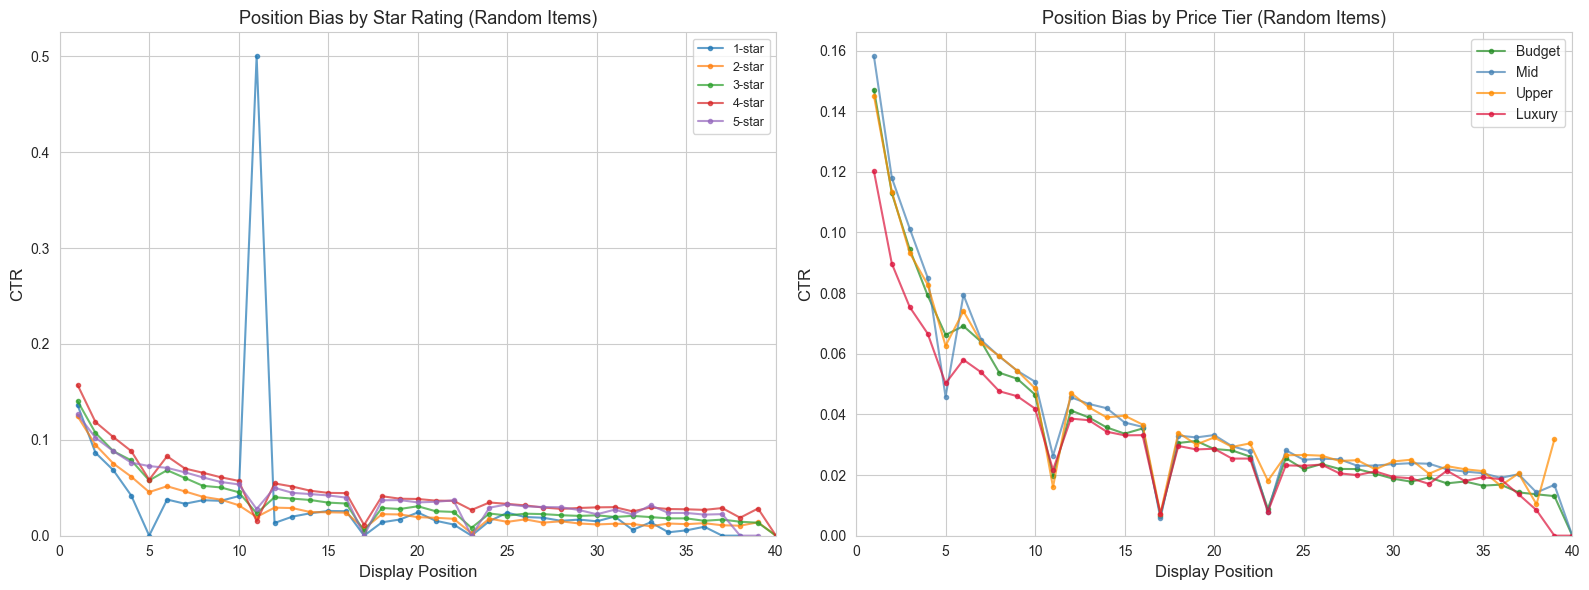

In [11]:
# Position bias by star rating (for random items only)
random_df = df[df['random_bool'] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: CTR by position for different star ratings
ax1 = axes[0]
for star in sorted(random_df['prop_starrating'].unique()):
    if star == 0:
        continue
    subset = random_df[random_df['prop_starrating'] == star]
    ctr = subset.groupby('position')['click_bool'].mean()
    ax1.plot(ctr.index, ctr.values, 'o-', markersize=3, alpha=0.7,
             label=f'{int(star)}-star')

ax1.set_xlabel('Display Position', fontsize=12)
ax1.set_ylabel('CTR', fontsize=12)
ax1.set_title('Position Bias by Star Rating (Random Items)', fontsize=13)
ax1.legend(fontsize=9)
ax1.set_xlim(0, min(40, random_df['position'].max()))
ax1.set_ylim(bottom=0)

# Right: CTR by position for price tiers
ax2 = axes[1]
price_quantiles = pd.qcut(random_df['price_usd'], q=4, labels=['Budget', 'Mid', 'Upper', 'Luxury'])
random_df['price_tier'] = price_quantiles.values

colors = ['forestgreen', 'steelblue', 'darkorange', 'crimson']
for tier, color in zip(['Budget', 'Mid', 'Upper', 'Luxury'], colors):
    subset = random_df[random_df['price_tier'] == tier]
    ctr = subset.groupby('position')['click_bool'].mean()
    ax2.plot(ctr.index, ctr.values, 'o-', markersize=3, alpha=0.7,
             color=color, label=tier)

ax2.set_xlabel('Display Position', fontsize=12)
ax2.set_ylabel('CTR', fontsize=12)
ax2.set_title('Position Bias by Price Tier (Random Items)', fontsize=13)
ax2.legend(fontsize=10)
ax2.set_xlim(0, min(40, random_df['position'].max()))
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

## 8. Booking Rate vs Click Rate by Position

Booking behaviour may show different position bias patterns than clicks. Users who book likely examine more items before making a decision, so the position decay might be less steep for bookings.

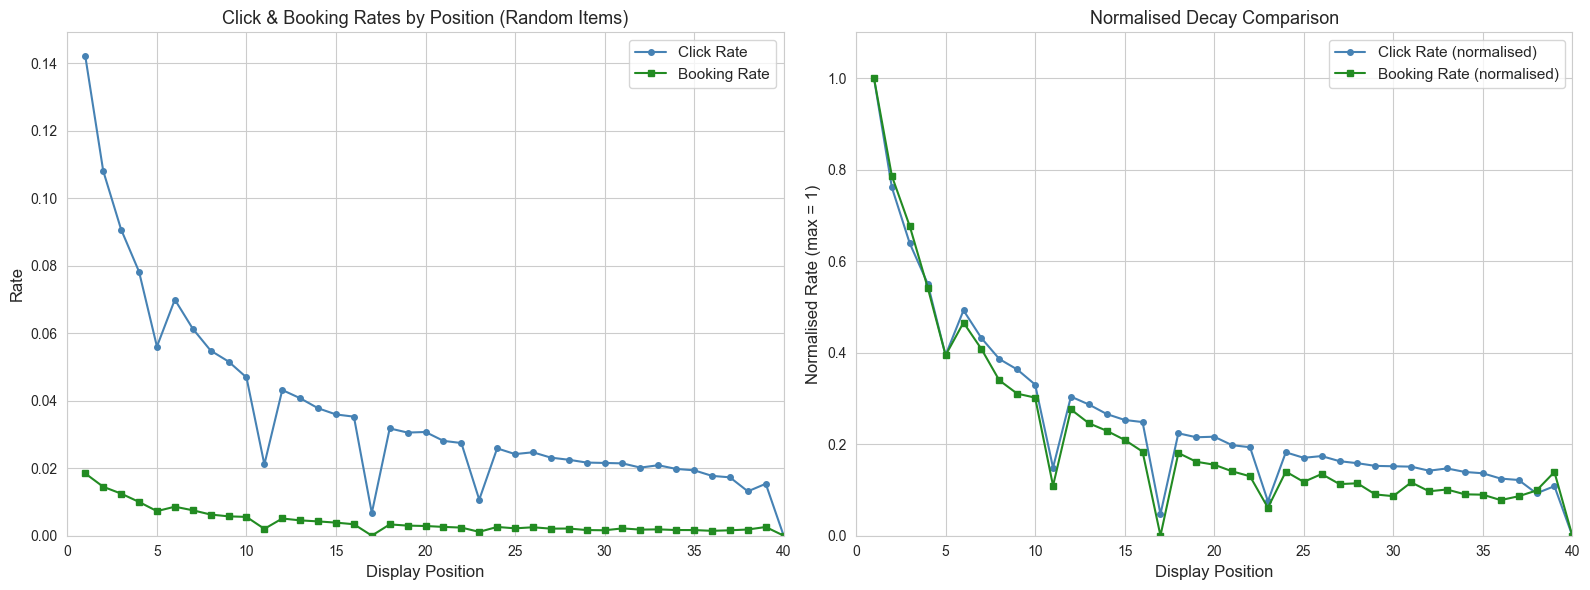

In [12]:
# Click rate vs Booking rate by position (random items)
random_ctr = random_df.groupby('position')['click_bool'].mean()
random_br = random_df.groupby('position')['booking_bool'].mean()

# Normalise to [0, 1] for comparison
ctr_norm = random_ctr / random_ctr.max() if random_ctr.max() > 0 else random_ctr
br_norm = random_br / random_br.max() if random_br.max() > 0 else random_br

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Raw rates
ax1 = axes[0]
ax1.plot(random_ctr.index, random_ctr.values, 'o-', color='steelblue',
         markersize=4, label='Click Rate')
ax1.plot(random_br.index, random_br.values, 's-', color='forestgreen',
         markersize=4, label='Booking Rate')
ax1.set_xlabel('Display Position', fontsize=12)
ax1.set_ylabel('Rate', fontsize=12)
ax1.set_title('Click & Booking Rates by Position (Random Items)', fontsize=13)
ax1.legend(fontsize=11)
ax1.set_xlim(0, min(40, random_ctr.index.max()))
ax1.set_ylim(bottom=0)

# Right: Normalised rates (to compare decay shape)
ax2 = axes[1]
common_pos = sorted(set(ctr_norm.index) & set(br_norm.index))
ax2.plot(common_pos, [ctr_norm.get(p, np.nan) for p in common_pos],
         'o-', color='steelblue', markersize=4, label='Click Rate (normalised)')
ax2.plot(common_pos, [br_norm.get(p, np.nan) for p in common_pos],
         's-', color='forestgreen', markersize=4, label='Booking Rate (normalised)')
ax2.set_xlabel('Display Position', fontsize=12)
ax2.set_ylabel('Normalised Rate (max = 1)', fontsize=12)
ax2.set_title('Normalised Decay Comparison', fontsize=13)
ax2.legend(fontsize=11)
ax2.set_xlim(0, min(40, max(common_pos) if common_pos else 40))
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## 9. Summary of IPS Weights

Let's look at the final weight distribution by position to confirm our debiasing makes sense.

In [13]:
# Final summary table
positions_to_show = [1, 2, 3, 5, 10, 15, 20, 25, 30, 35, 40]
summary_data = []

for pos in positions_to_show:
    prop = propensity_func(pos)
    ips_w = 1.0 / max(prop, 1e-6)
    summary_data.append({
        'Position': pos,
        'Propensity P(examine|pos)': f'{prop:.4f}',
        'IPS Weight (1/P)': f'{ips_w:.2f}',
        'Interpretation': 'High examination' if prop > 0.1 else ('Moderate' if prop > 0.03 else 'Low examination')
    })

summary_table = pd.DataFrame(summary_data)
print("=" * 70)
print("PROPENSITY & IPS WEIGHT SUMMARY")
print("=" * 70)
print(summary_table.to_string(index=False))
print(f"\nPower-law model: P(examine | pos) = {alpha:.4f} * pos^(-{beta:.4f})")
print(f"IPS clip percentile: {IPS_CLIP_PERCENTILE}th")

PROPENSITY & IPS WEIGHT SUMMARY
 Position Propensity P(examine|pos) IPS Weight (1/P)   Interpretation
        1                    0.1536             6.51 High examination
        2                    0.1037             9.64 High examination
        3                    0.0824            12.13         Moderate
        5                    0.0617            16.20         Moderate
       10                    0.0417            23.99         Moderate
       15                    0.0331            30.18         Moderate
       20                    0.0282            35.52  Low examination
       25                    0.0248            40.31  Low examination
       30                    0.0224            44.69  Low examination
       35                    0.0205            48.77  Low examination
       40                    0.0190            52.60  Low examination

Power-law model: P(examine | pos) = 0.1536 * pos^(-0.5663)
IPS clip percentile: 95th


## Key Takeaways

1. **Position bias is strong**: CTR drops dramatically from position 1 to lower positions, confirming that users examine top results much more frequently.

2. **Random items isolate examination bias**: The `random_bool` column lets us cleanly separate examination probability from relevance -- a rare and valuable signal in the dataset.

3. **Power-law fit is appropriate**: The log-log plot shows an approximately linear relationship, validating the $\alpha \cdot \text{pos}^{-\beta}$ model.

4. **IPS corrects the bias**: After IPS reweighting, items shown at low positions with genuine user interest receive higher effective weights. This teaches the model to recognise true relevance rather than memorising the old ranker's ordering.

5. **Weight clipping is essential**: Without clipping, weights for items at very low positions could be enormous (e.g., 50x or 100x), destabilising gradient-based training. The 95th percentile clip balances debiasing strength with training stability.

6. **Booking behaviour has different position dynamics**: The booking rate decay by position is typically less steep than the click rate decay, because booking decisions involve more deliberate examination.

See Notebook 04 for how these IPS weights are integrated into LGBMRanker training via the `sample_weight` parameter.